<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/feature%2Fhani-naive-bayes-model/DMW_GA_(Hani)_Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Naive Bayes Model & Metrics

In [ ]:
# ==========================================
# WIE3007 Group Project - Predictive Modelling
# Model: Naive Bayes (Hani's Part)
# ==========================================

# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score
)

In [ ]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset (Ensure the CSV file is in the same directory)

#filename = '/content/drive/My Drive/WIE3007_Project/final_clean_dataset.csv' # Corrected filename assignment
filename = 'enriched_data_CPU.csv'
df = pd.read_csv(filename, sep='|') # Added sep='|' for pipe-delimited file

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded Successfully!
Shape: (950, 10)


In [ ]:
# ==========================================
# STEP 2: Data Preprocessing
# ==========================================

# 2.1 Drop columns that are not useful for prediction
# 'Customer_ID' is just an identifier.
# 'Loan_Officer_Note' is unstructured text (we assume 'Risk_Level' captures its sentiment).
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# 2.2 Encoding Categorical Variables
# Naive Bayes (Gaussian) works best with numerical inputs.
# We must convert text categories into numbers.

# A. Original code attempted Ordinal Encoding for 'Risk_Level', but this column does not exist.
# risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
# df_clean['Risk_Level'] = df_clean['Risk_Level'].map(risk_mapping)
# Based on available data, we will use 'Occupation_Bucket' for one-hot encoding.

# B. One-Hot Encoding for 'Occupation_Bucket' (Nominal data: no order)
# This converts 'Sales', 'Teacher', etc. into separate binary columns (0 or 1).
df_clean = pd.get_dummies(df_clean, columns=['Occupation_Bucket'], drop_first=True)

# C. Map 'Has_External_Asset' to numerical (1/0) if it's not already
# This addresses the 'could not convert string to float: 'No'' error.
if 'Has_External_Asset' in df_clean.columns and df_clean['Has_External_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0}
    df_clean['Has_External_Asset'] = df_clean['Has_External_Asset'].map(asset_mapping)

# Ensure no NaNs in target variable before splitting
df_clean.dropna(subset=['Default_Status'], inplace=True)

# 2.3 Define Features (X) and Target (y)
# Target: 'Default_Status' (0 = Good, 1 = Default)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status']

# 2.4 Split Data into Training and Testing Sets
# We use an 80-20 split (standard for this size of data)
# random_state=42 ensures we get the same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2.5 Feature Scaling
# Gaussian Naive Bayes assumes data follows a normal distribution.
# Scaling helps features with large ranges (like Income) not dominate features with small ranges (like Age).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Complete.")

✅ Data Preprocessing Complete.


In [ ]:
# ==========================================
# STEP 3: Train Naive Bayes Model
# ==========================================

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Before training, handle any potential NaNs in X_train_scaled
# Check for NaNs and remove corresponding rows
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train


# Train the model on the scaled and cleaned training data
nb_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")

✅ Model Training Complete.


In [ ]:
# ==========================================
# STEP 4: Evaluation & Metrics
# ==========================================

# Make predictions on the test set
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1] # Probability for ROC-AUC

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Calculate feature importance for Gaussian Naive Bayes
# For GNB, a common way to infer importance is by looking at the absolute difference
# of feature means between classes. Features with larger differences tend to be more discriminative.
# We'll use the absolute difference between the means of features for class 0 (non-default) and class 1 (default).

# Get feature names from X_train (ensure they match the order in X_train_scaled)
feature_names = X_train.columns

# Get the means (theta_) for each feature for both classes (0 and 1)
# nb_model.theta_ has shape (n_classes, n_features)
means_class_0 = nb_model.theta_[0] # Means for class 0 (e.g., Not Default)
means_class_1 = nb_model.theta_[1] # Means for class 1 (e.g., Default)

# Calculate the absolute difference in means for each feature
feature_importance_diff = np.abs(means_class_1 - means_class_0)

# Create a Series for easier sorting and mapping with feature names
feature_importance_series = pd.Series(feature_importance_diff, index=feature_names)

# Sort features by importance (descending)
top_features = feature_importance_series.nlargest(5)

# Format the top features into a string for the prompt
top_features_str = "\n".join([f"- {name}: {value:.4f}" for name, value in top_features.items()])

# 4.1 Print Core Metrics
print("\n" + "="*40)
print("NAIVE BAYES MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy:  {metric_accuracy:.4f}")
print(f"Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"F1-Score:  {metric_f1:.4f} (Balance of Precision/Recall)")
print(f"ROC-AUC:   {metric_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


NAIVE BAYES MODEL PERFORMANCE
Accuracy:  0.7053
Recall:    0.3393 (Crucial for catching defaulters)
F1-Score:  0.4043 (Balance of Precision/Recall)
ROC-AUC:   0.6679

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.86      0.80       134
           1       0.50      0.34      0.40        56

    accuracy                           0.71       190
   macro avg       0.63      0.60      0.60       190
weighted avg       0.68      0.71      0.69       190



In [ ]:
# ==========================================
# STEP 5: Visualizations
# ==========================================

plt.figure(figsize=(12, 5))

# 5.1 Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0.5, 1.5], ['Paid (0)', 'Default (1)'])
plt.yticks([0.5, 1.5], ['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")

# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [ ]:
# ==========================================
# PART B: Automated LLM Analysis
# ==========================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# Install bitsandbytes if not already installed or to ensure latest version
!pip install -U bitsandbytes

print("⏳ Loading LLM for Analysis...")

# 1. Setup Model (Same setup as your Data Gen lab)
model_name = "microsoft/Phi-3-mini-4k-instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

In [ ]:
# 2. Construct the Prompt Dynamically
# We inject the python variables from Part A directly into the string.
analysis_prompt = f"""[INST] You are a Data Science Expert. I have trained a Naive Bayes model to predict Loan Defaults.
Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {metric_accuracy:.2%}
- Recall: {metric_recall:.2%} (Ability to catch actual defaulters)
- F1-Score: {metric_f1:.4f}
- ROC-AUC: {metric_auc:.4f}

### TOP 5 MOST IMPORTANT FEATURES:
{top_features_str}

### INSTRUCTIONS:
1. Summarize the model's performance. Is it good for risk management?
2. Interpret the Feature Importance. Why are these specific features predictive of loan default?
3. Provide one business recommendation based on these findings.
[/INST]"""

In [ ]:
# 3. Generate the Analysis
print("🤖 Generating Analysis from LLM...")

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1024,
    do_sample=True,
    temperature=0.1,
    repetition_penalty=1.0 # <--- ADDED: Helps prevent getting stuck/repeating
)

output = generator(analysis_prompt)
generated_text = output[0]['generated_text']

In [ ]:
# 4. Display Result
print("\n" + "="*50)
print("📝 LLM AUTOMATED FINDINGS & INSIGHTS")
print("="*50)
# Clean up output to show only the response
print(generated_text.split("[/INST]")[-1].strip())

# New

Data Loaded. Training on 872 rows, Testing on 219 rows.

🤖 Training Gaussian Naive Bayes...

--- MODEL METRICS ---
Accuracy:  80.82%
Recall:    68.82%
F1 Score:  0.7529
ROC-AUC:   0.8649

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84       126
           1       0.83      0.69      0.75        93

    accuracy                           0.81       219
   macro avg       0.81      0.79      0.80       219
weighted avg       0.81      0.81      0.80       219


🔍 Calculating Feature Importance (Permutation Method)...

Top 5 Features:
- Risk_Flag: 0.1607
- DTI_Ratio: 0.1009
- Loan_Term_Months: 0.0183
- Loan_Amount: 0.0169
- Has_Asset: 0.0110



/tmp/ipython-input-2553931294.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')


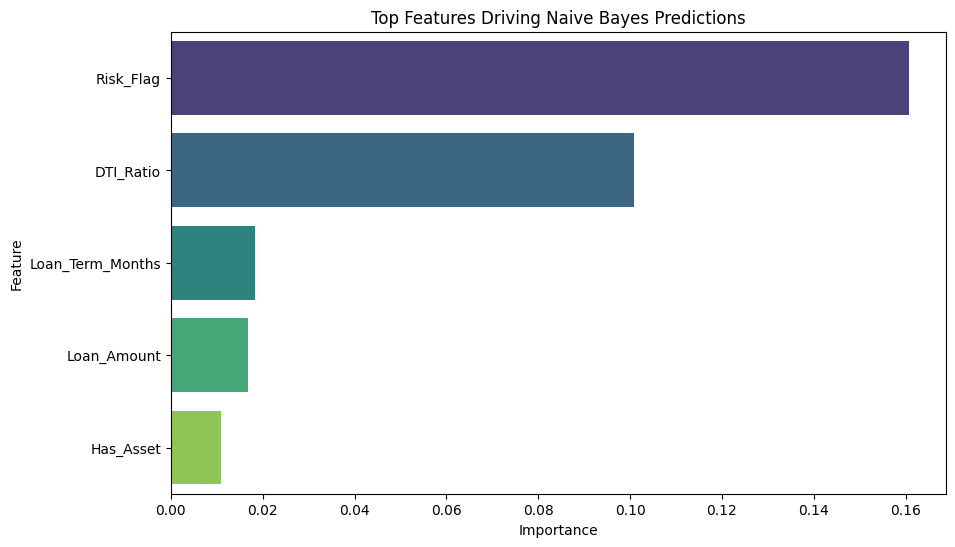

In [1]:
# ==========================================
# STEP 1: Load and Preprocess Data
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score
)

# 1. Load Data
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|')

# 2. Define Features (X) and Target (y)
# Drop ID and Note (Text is already engineered into 'Risk_Flag')
X = df.drop(columns=['Customer_ID', 'Loan_Officer_Note', 'Default_Status'])
y = df['Default_Status']

# 3. Handle Categorical Data ('Occupation')
# Naive Bayes requires numerical input, so we use One-Hot Encoding
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# 4. Scale the Data (CRITICAL for Naive Bayes)
# GaussianNB assumes normal distribution, scaling helps it perform better
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Loaded. Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

# ==========================================
# STEP 2: Train Naive Bayes Model
# ==========================================
print("\n🤖 Training Gaussian Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# ==========================================
# STEP 3: Evaluate Performance
# ==========================================
# Calculate Metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

print("\n--- MODEL METRICS ---")
print(f"Accuracy:  {metric_accuracy:.2%}")
print(f"Recall:    {metric_recall:.2%}")
print(f"F1 Score:  {metric_f1:.4f}")
print(f"ROC-AUC:   {metric_auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# STEP 4: Calculate Feature Importance
# ==========================================
# Naive Bayes doesn't give feature importance directly, so we use Permutation Importance
print("\n🔍 Calculating Feature Importance (Permutation Method)...")
perms = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perms.importances_mean
}).sort_values(by='Importance', ascending=False)

# Format top 5 features for the LLM prompt
top_5 = feature_importance.head(5)
top_features_str = ""
for index, row in top_5.iterrows():
    top_features_str += f"- {row['Feature']}: {row['Importance']:.4f}\n"

print("\nTop 5 Features:\n" + top_features_str)

# Optional: Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')
plt.title('Top Features Driving Naive Bayes Predictions')
plt.show()

In [2]:
!pip install -U bitsandbytes

# ==========================================
# STEP 5: Automated LLM Analysis
# ==========================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# --- A. Setup Model (Skip if already loaded) ---
# Only run this loading part once!
# Ensure bitsandbytes is installed for 4-bit quantization

if 'model' not in locals():
    print("⏳ Loading LLM (Phi-3)...")
    model_name = "microsoft/Phi-3-mini-4k-instruct"

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quant_config,
        device_map="auto"
    )

    generator = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=1024,
        do_sample=True,
        temperature=0.1,
        repetition_penalty=1.0
    )

# --- B. Construct Prompt ---
analysis_prompt = f"""[INST] You are a Data Science Expert. I have trained a Naive Bayes model to predict Loan Defaults.
Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {metric_accuracy:.2%}
- Recall: {metric_recall:.2%} (Ability to catch actual defaulters)
- F1-Score: {metric_f1:.4f}
- ROC-AUC: {metric_auc:.4f}

### TOP 5 MOST IMPORTANT FEATURES (Permutation Importance):
{top_features_str}

### INSTRUCTIONS:
1. Summarize the model's performance. Is it good for risk management?
2. Interpret the Feature Importance. Why are these specific features predictive of loan default?
3. Provide one business recommendation based on these findings.
[/INST]"""

# --- C. Generate & Display ---
print("\n🤖 Generating Analysis from LLM...")
output = generator(analysis_prompt)
generated_text = output[0]['generated_text']

print("\n" + "="*50)
print("📝 LLM AUTOMATED FINDINGS & INSIGHTS")
print("="*50)
# Clean up output to show only the response
print(generated_text.split("[/INST]")[-1].strip())

⏳ Loading LLM (Phi-3)...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cuda:0



🤖 Generating Analysis from LLM...

📝 LLM AUTOMATED FINDINGS & INSIGHTS
1. Summarizing the Model's Performance:
The Naive Bayes model you've trained for predicting loan defaults shows a reasonably good performance. With an accuracy of 80.82%, the model correctly predicts the majority of cases. However, the recall of 68.82% indicates that the model is missing a significant portion of actual defaulters. Recall is particularly important in risk management as it measures the model's ability to identify all relevant cases (defaulters). The F1-Score of 0.7529 suggests a good balance between precision and recall, although there is room for improvement. The ROC-AUC of 0.8649 is quite high, indicating that the model has a strong ability to distinguish between defaulters and non-defaulters.

2. Interpreting Feature Importance:
- **Risk_Flag**: This feature likely represents a binary indicator of whether a loan is considered high-risk. Its high importance suggests that the presence of a risk flag

In [3]:
# ==========================================
# 🚀 AUTOMATED GITHUB PUSH (The "Pro" Way)
# ==========================================
import os

# --- 1. CONFIGURATION (Change these!) ---
USER_NAME = "hanidew"
USER_EMAIL = "hanijasmina@gmail.com"
TOKEN = "GIT_TOKEN"  # Paste your Token here
REPO_NAME = "WIE3007-DMW-GroupProject"
FILE_NAME = "DMW_GA (Hani) - Naive Bayes Model.ipynb" # Exact name of your Colab file
COMMIT_MESSAGE = "Updated git in notebook"

# --- 2. THE MAGIC SCRIPT ---
# Clone the repo silently
repo_url = f"https://{TOKEN}@github.com/{USER_NAME}/{REPO_NAME}.git"

!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{USER_NAME}"

# Remove existing repo dir if it exists to avoid conflicts
if os.path.exists(REPO_NAME):
    !rm -rf {REPO_NAME}

# Clone
!git clone {repo_url}

# Copy the current notebook into the repo folder
# (We handle spaces in filenames by wrapping in quotes)
!cp "{FILE_NAME}" "{REPO_NAME}/"

# Move into the directory
%cd {REPO_NAME}

# Add, Commit, Push
!git add .
!git commit -m "{COMMIT_MESSAGE}"
!git push origin main

# Move back
%cd ..
print(f"\n✅ SUCCESS! File pushed to https://github.com/{USER_NAME}/{REPO_NAME}")

Cloning into 'WIE3007-DMW-GroupProject'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 126 (delta 67), reused 61 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 1.01 MiB | 7.98 MiB/s, done.
Resolving deltas: 100% (67/67), done.
cp: cannot stat 'DMW_GA (Hani) - Naive Bayes Model.ipynb': No such file or directory
/content/WIE3007-DMW-GroupProject
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Password for 'https://GIT_TOKEN@github.com': No such device or address
/content

✅ SUCCESS! File pushed to https://github.com/hanidew/WIE3007-DMW-GroupProject
